# WSJCAM0 Autoregressive Speech Prediction

This notebook assumes the server environment is already prepared.

Before running this notebook:

1. install dependencies from the terminal by following `INSTALL_SERVER.md`
2. switch the notebook kernel to `Python (finalproject26-py39)`
3. run the cells below


In [1]:
from pathlib import Path
import os
import warnings

warnings.filterwarnings('ignore')

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'src').exists() else NOTEBOOK_DIR.parent
os.chdir(ROOT)
print(f'Project root: {ROOT}')
print(f'Dataset root exists: {(ROOT / "wsj0").exists()}')


Project root: /root/autodl-tmp/DL_Final
Dataset root exists: True


In [2]:
HF_ENDPOINT = 'https://hf-mirror.com'
os.environ['HF_ENDPOINT'] = HF_ENDPOINT
os.environ['HUGGINGFACE_HUB_ENDPOINT'] = HF_ENDPOINT
print('HF_ENDPOINT =', os.environ['HF_ENDPOINT'])


HF_ENDPOINT = https://hf-mirror.com


In [3]:
import sys

import pandas as pd
import torch
import torchaudio

print('Python executable:', sys.executable)
print('Python version:', sys.version.split()[0])
print('Torch:', torch.__version__)
print('Torchaudio:', torchaudio.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


Python executable: /root/miniconda3/envs/finalproject26-py39/bin/python
Python version: 3.9.25
Torch: 2.8.0+cu128
Torchaudio: 2.8.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5090


In [10]:
from src.data.manifest import build_wsj0_manifest

train_manifest = build_wsj0_manifest('wsj0', 'si_tr_s')
val_manifest = build_wsj0_manifest('wsj0', 'si_dt_05')
test_manifest = build_wsj0_manifest('wsj0', 'si_et_05')
pd.DataFrame([
    {'split': 'si_tr_s', 'num_files': len(train_manifest)},
    {'split': 'si_dt_05', 'num_files': len(val_manifest)},
    {'split': 'si_et_05', 'num_files': len(test_manifest)},
])


,split,num_files
0,si_tr_s,12776
1,si_dt_05,1206
2,si_et_05,651


In [12]:
from src.experiment import build_report_assets, compare_codecs, run_codec_experiment

SMOKE_RUN = False
DATASET_ROOT = 'wsj0'
ARTIFACTS_DIR = 'artifacts'
REPORT_DIR = f'{ARTIFACTS_DIR}/report'

COMMON_OVERRIDES = {
    'dataset': {
        'root': DATASET_ROOT,
    },
    'project': {
        'artifacts_dir': ARTIFACTS_DIR,
    },
    'codecs': {
        'hub_endpoint': HF_ENDPOINT,
    },
}

if SMOKE_RUN:
    COMMON_OVERRIDES = {
        **COMMON_OVERRIDES,
        'training': {
            'batch_size': 2,
            'num_workers': 0,
            'max_epochs': 1,
            'context_frames': 40,
            'log_every_epochs': 1,
        },
        'evaluation': {
            'max_eval_files': 8,
            'save_audio_examples': 2,
        },
    }

COMMON_OVERRIDES

{'dataset': {'root': 'wsj0'},
 'project': {'artifacts_dir': 'artifacts'},
 'codecs': {'hub_endpoint': 'https://hf-mirror.com'}}

In [6]:
facodec_config, facodec_train, facodec_eval = run_codec_experiment('facodec', overrides=COMMON_OVERRIDES)
print(facodec_train)
print(facodec_eval)


[facodec] cleared previous checkpoints, history, and evaluation artifacts


train epoch 1:   0%|          | 0/400 [00:00<?, ?it/s]

validation:   0%|          | 0/38 [00:00<?, ?it/s]

[facodec] epoch 001/010 train_loss=1.6841 val_loss=1.9720 train_pre=1.2373 train_post=2.2336 val_pre=1.4909 val_post=2.4054 best_val=1.9720


train epoch 2:   0%|          | 0/400 [00:00<?, ?it/s]

...

validation:   0%|          | 0/38 [00:00<?, ?it/s]

[facodec] epoch 010/010 train_loss=1.6651 val_loss=1.8853 train_pre=1.2483 train_post=2.0843 val_pre=1.4939 val_post=1.9571 best_val=1.8853


evaluate facodec:   0%|          | 0/651 [00:00<?, ?it/s]

downloading https://raw.githubusercontent.com/microsoft/DNS-Challenge/master/DNSMOS/DNSMOS/model_v8.onnx to /root/.torchmetrics/DNSMOS/DNSMOS/model_v8.onnx
downloading https://raw.githubusercontent.com/microsoft/DNS-Challenge/master/DNSMOS/DNSMOS/sig_bak_ovr.onnx to /root/.torchmetrics/DNSMOS/DNSMOS/sig_bak_ovr.onnx
downloading https://raw.githubusercontent.com/microsoft/DNS-Challenge/master/DNSMOS/pDNSMOS/sig_bak_ovr.onnx to /root/.torchmetrics/DNSMOS/pDNSMOS/sig_bak_ovr.onnx


TrainArtifacts(run_dir='artifacts/facodec', checkpoint_path='artifacts/facodec/checkpoints/best.pt', train_manifest_path='artifacts/manifests/facodec_train.csv', val_manifest_path='artifacts/manifests/facodec_val.csv', history_path='artifacts/facodec/history.json')
EvaluationArtifacts(manifest_path='artifacts/facodec/evaluation/test_manifest.csv', per_utterance_path='artifacts/facodec/evaluation/per_utterance_metrics.csv', summary_path='artifacts/facodec/evaluation/summary_metrics.json', samples_dir='artifacts/facodec/evaluation/samples')


In [6]:
encodec_config, encodec_train, encodec_eval = run_codec_experiment('encodec', overrides=COMMON_OVERRIDES)
print(encodec_train)
print(encodec_eval)


[encodec] cleared previous checkpoints, history, and evaluation artifacts


train epoch 1:   0%|          | 0/400 [00:00<?, ?it/s]

validation:   0%|          | 0/38 [00:00<?, ?it/s]

[encodec] epoch 001/010 train_loss=1.4733 val_loss=1.6395 train_pre=1.2705 train_post=1.0140 val_pre=1.3975 val_post=1.2099 best_val=1.6395


train epoch 2:   0%|          | 0/400 [00:00<?, ?it/s]

...

train epoch 10:   0%|          | 0/400 [00:00<?, ?it/s]

validation:   0%|          | 0/38 [00:00<?, ?it/s]

[encodec] epoch 010/010 train_loss=1.3893 val_loss=1.5331 train_pre=1.2008 train_post=0.9424 val_pre=1.2853 val_post=1.2394 best_val=1.5331


evaluate encodec:   0%|          | 0/651 [00:00<?, ?it/s]

TrainArtifacts(run_dir='artifacts/encodec', checkpoint_path='artifacts/encodec/checkpoints/best.pt', train_manifest_path='artifacts/manifests/encodec_train.csv', val_manifest_path='artifacts/manifests/encodec_val.csv', history_path='artifacts/encodec/history.json')
EvaluationArtifacts(manifest_path='artifacts/encodec/evaluation/test_manifest.csv', per_utterance_path='artifacts/encodec/evaluation/per_utterance_metrics.csv', summary_path='artifacts/encodec/evaluation/summary_metrics.json', samples_dir='artifacts/encodec/evaluation/samples')


In [8]:
summary_table = compare_codecs({
  'facodec': 'artifacts/facodec/evaluation/summary_metrics.json',
  'encodec': 'artifacts/encodec/evaluation/summary_metrics.json',
})
summary_table.to_csv(Path(ARTIFACTS_DIR) / 'codec_comparison.csv', index=False)
summary_table


,codec,num_files,stoi_mean,stoi_std,pesq_mean,pesq_std,dnsmos_mean,dnsmos_std
0,encodec,651,0.335698,0.124314,1.196353,0.366403,1.106710,0.015287
1,facodec,651,0.362790,0.127164,1.080040,0.103604,1.350038,0.265406


In [14]:
report_assets = build_report_assets(
  history_paths={
      'facodec': 'artifacts/facodec/history.json',
      'encodec': 'artifacts/encodec/history.json',
  },
  summary_paths={
      'facodec': 'artifacts/facodec/evaluation/summary_metrics.json',
      'encodec': 'artifacts/encodec/evaluation/summary_metrics.json',
  },
  output_dir=REPORT_DIR,
)
report_assets['summary_dataframe']


,codec,num_files,stoi_mean,stoi_std,pesq_mean,pesq_std,dnsmos_mean,dnsmos_std
0,encodec,651,0.335698,0.124314,1.196353,0.366403,1.106710,0.015287
1,facodec,651,0.362790,0.127164,1.080040,0.103604,1.350038,0.265406


In [16]:
from IPython.display import Image, display

Report materials saved to: artifacts/report
Tables: {'csv': 'artifacts/report/codec_summary.csv', 'markdown': 'artifacts/report/codec_summary.md', 'latex': 'artifacts/report/codec_summary.tex'}
Curves: {'facodec': 'artifacts/report/facodec_training_curves.png', 'encodec': 'artifacts/report/encodec_training_curves.png'}
Metric comparison: artifacts/report/codec_metric_comparison.png


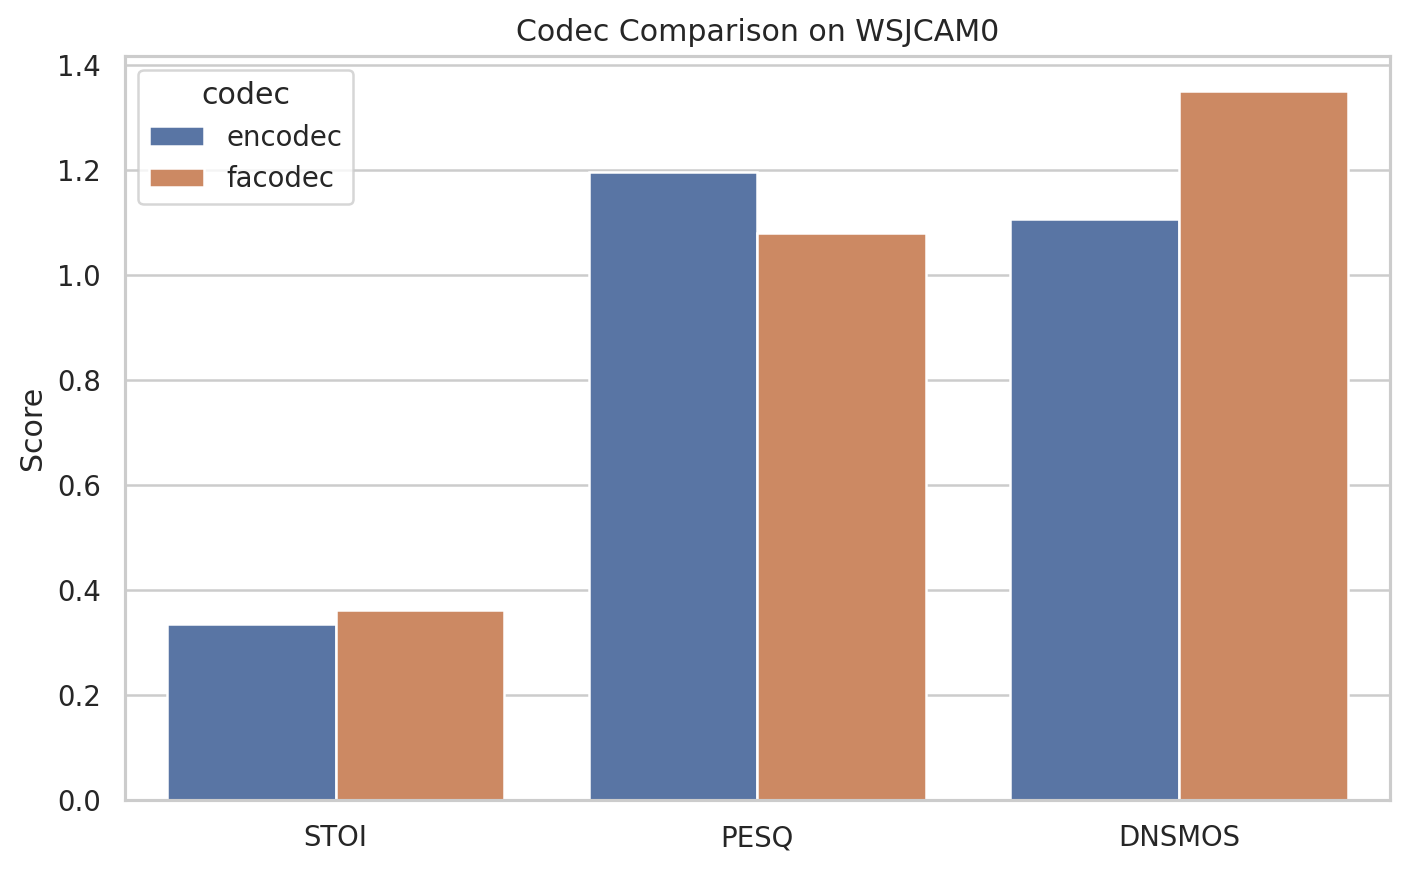

facodec artifacts/report/facodec_training_curves.png


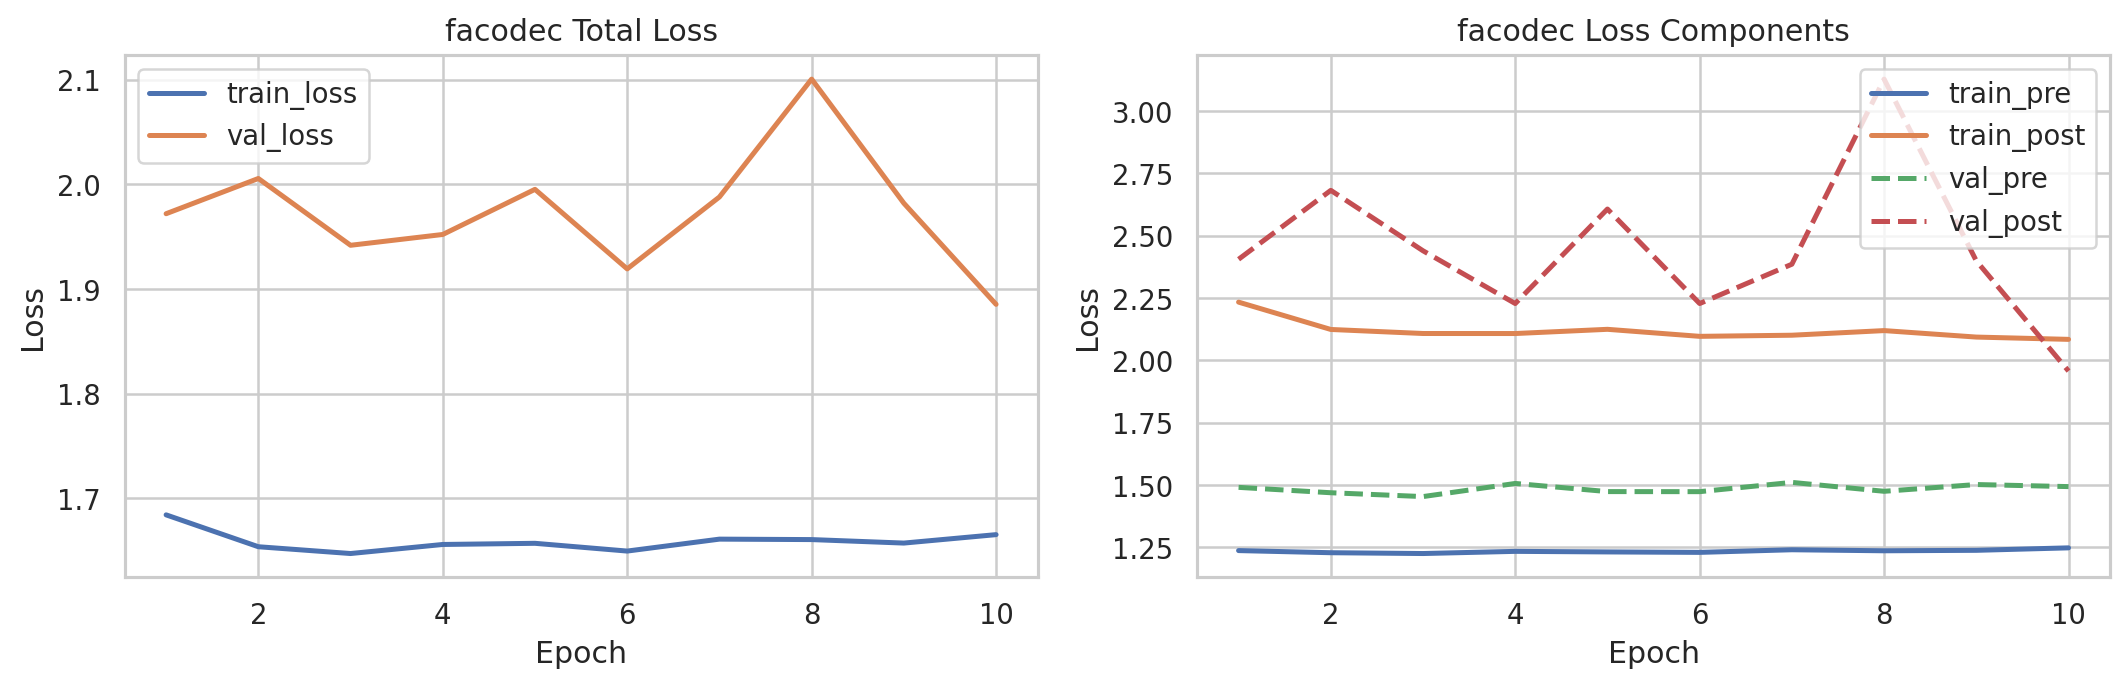

encodec artifacts/report/encodec_training_curves.png


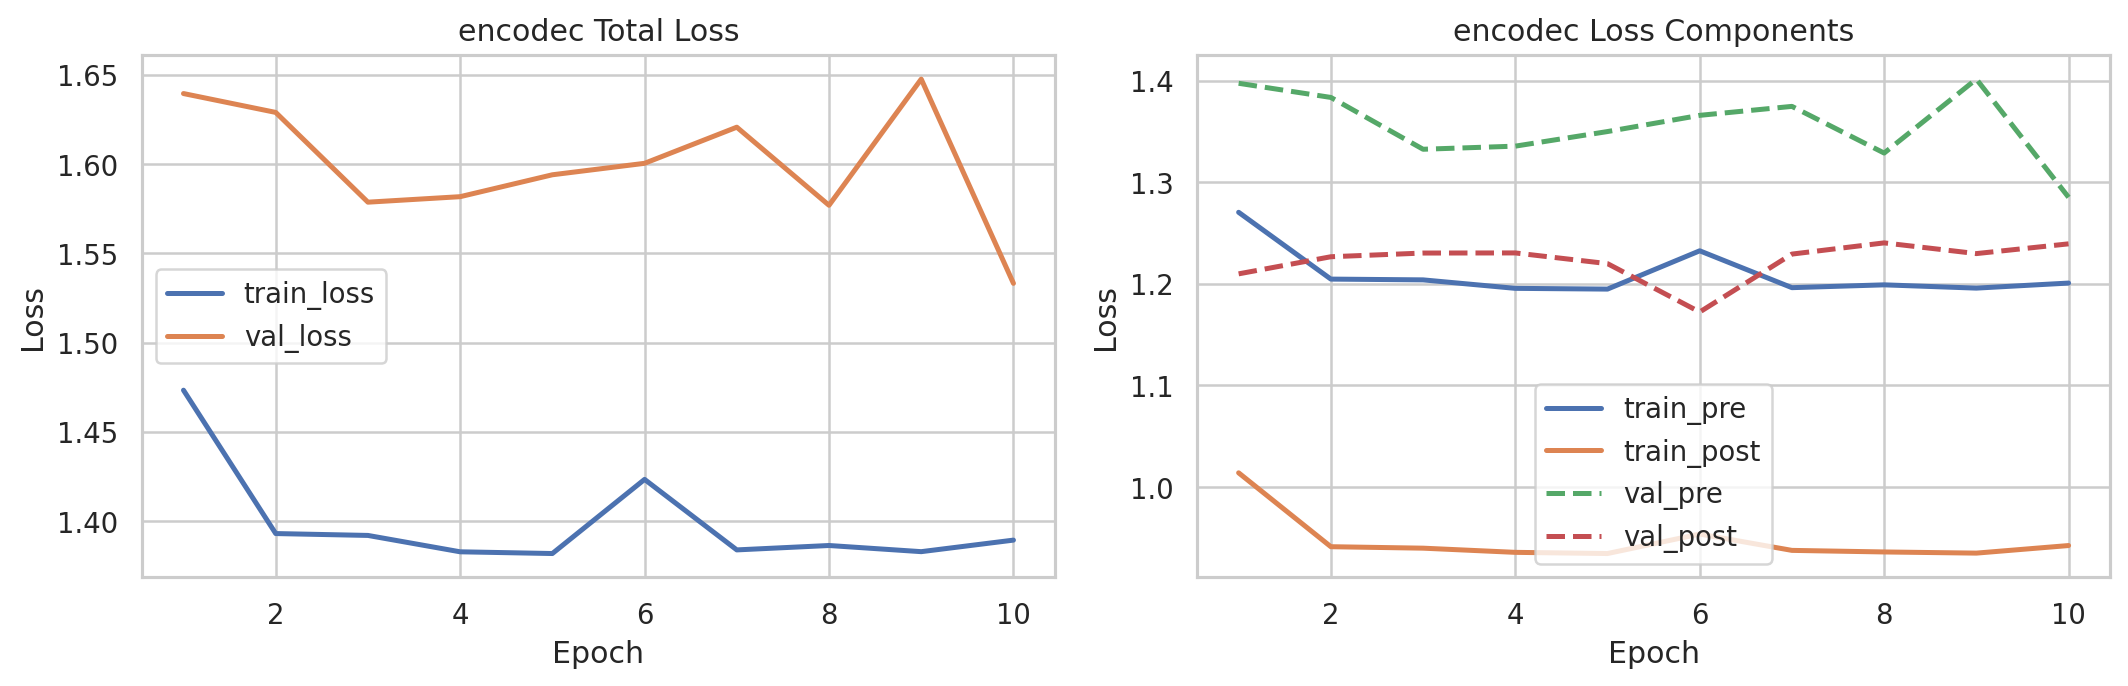

In [17]:
print('Report materials saved to:', report_assets['output_dir'])
print('Tables:', report_assets['table_paths'])
print('Curves:', report_assets['curve_paths'])
print('Metric comparison:', report_assets['comparison_plot'])
display(Image(filename=report_assets['comparison_plot']))
for codec_name, image_path in report_assets['curve_paths'].items():
    print(codec_name, image_path)
    display(Image(filename=image_path))
